# BCSD Daily Pipeline + Paper-Style Evaluation — Xu & Wang (2019) / Tran-Anh (2023)
**ACCESS-CM2 Tmax → CHIRTS 0.05° over India**

This single notebook merges:
  1. The full BCSD pipeline (detrend → QM bias-correct → IDW spatial disaggregation)
  2. The 8-figure paper-style evaluation suite

The pipeline produces yearly `step3_sd_<year>.nc` files; the evaluation reads them
back. Run top to bottom. Functions defined once (no duplicates).

In [2]:
!pip install regionmask geopandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 2.1 MB/s eta 0:00:00


In [3]:
!pip install netCDF4 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 65.4 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 45.2 MB/s eta 0:00:00:00:01


In [19]:
import numpy as np
import xarray as xr
import pandas as pd
import glob, os, shutil
import time as timer
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')


In [20]:
BASE = "/kaggle/input/datasets/kalpitasaha/bcsd-24-6-26"

class Config:
    CHIRTS_005_DIR  = f'{BASE}/chirtstmax_005_clean'
    CHIRTS_1DEG_DIR = f'{BASE}/chirtstmax_1deg'
    GCM_1DEG_DIR    = f'{BASE}/gcm_tasmax_regrid_1deg'
    SHAPEFILE_PATH  = f'{BASE}/target_shapefile/target (1).shp'
    WORK_DIR        = '/kaggle/working/bcsd_checkpoints'

    OBS_VAR = 'tmax'
    GCM_VAR = 'tasmax'

    TRAIN_START = 1983
    TRAIN_END   = 2014

    RUNNING_AVG_WINDOW = 9
    QM_DAY_WINDOW      = 15
    IDW_POWER          = 2
    IDW_N_NEIGHBORS    = 4

config = Config()

In [21]:
def run_diagnostics():
    """Check NaN, calendar, leap years, grid alignment, day counts."""
    import netCDF4

    print("=" * 65)
    print("  DIAGNOSTICS")
    print("=" * 65)

    datasets = [
        ('CHIRTS 0.05°', Config.CHIRTS_005_DIR, Config.OBS_VAR),
        ('CHIRTS 1°',    Config.CHIRTS_1DEG_DIR, Config.OBS_VAR),
        ('GCM 1°',       Config.GCM_1DEG_DIR,    Config.GCM_VAR),
    ]

    for label, directory, var in datasets:
        files = sorted(glob.glob(os.path.join(directory, '*.nc')))
        print(f"\n── {label}: {len(files)} files ──")

        total_nan = 0
        total_vals = 0
        total_feb29 = 0
        leap_years = []
        calendars = set()
        days_per_year = {}
        all_nan_cells_first = None
        valid_cells_first = None
        grid_shape = None
        lat_range = None
        lon_range = None
        fill_value_count = 0

        for fpath in files:
            # Calendar from raw netCDF4
            try:
                nc = netCDF4.Dataset(fpath, 'r')
                if 'time' in nc.variables and hasattr(nc.variables['time'], 'calendar'):
                    calendars.add(nc.variables['time'].calendar)
                nc.close()
            except:
                pass

            ds = xr.open_dataset(fpath)
            # Find variable
            v = var if var in ds else next((x for x in ds.data_vars if x.lower() == var.lower()), None)
            if v is None:
                print(f"  ❌ Variable '{var}' not found in {os.path.basename(fpath)}")
                ds.close()
                continue

            da = ds[v]
            vals = da.values
            total_vals += vals.size
            total_nan += int(np.isnan(vals).sum())

            # Fill value check
            valid = vals[~np.isnan(vals)]
            if len(valid) > 0:
                fill_value_count += int((valid == -9999).sum() + (valid < -200).sum())

            # Grid info from first file
            if grid_shape is None:
                # Find lat/lon
                lat_name = next((d for d in list(da.dims)+list(da.coords) if d.lower() in ('lat','latitude','y')), None)
                lon_name = next((d for d in list(da.dims)+list(da.coords) if d.lower() in ('lon','longitude','x')), None)
                if lat_name and lon_name:
                    lats = da[lat_name].values
                    lons = da[lon_name].values
                    grid_shape = f"{len(lats)}×{len(lons)}"
                    lat_range = f"{lats.min():.2f} to {lats.max():.2f}"
                    lon_range = f"{lons.min():.2f} to {lons.max():.2f}"
                all_nan_cells_first = int(np.all(np.isnan(vals), axis=0).sum())
                valid_cells_first = int((~np.all(np.isnan(vals), axis=0)).sum())

            # Time info
            if 'time' in da.dims:
                years = da.time.dt.year.values
                months = da.time.dt.month.values
                day_vals = da.time.dt.day.values
                yr = int(years[0])
                days_per_year[yr] = len(years)

                feb29 = ((months == 2) & (day_vals == 29))
                n_feb29 = int(feb29.sum())
                total_feb29 += n_feb29
                if n_feb29 > 0:
                    leap_years.extend([int(y) for y in set(years[feb29])])

            ds.close()

        nan_pct = round(100 * total_nan / total_vals, 2) if total_vals > 0 else 0
        print(f"  Calendar:      {calendars if calendars else 'unknown'}")
        print(f"  Grid:          {grid_shape}  lat={lat_range}  lon={lon_range}")
        print(f"  All-NaN cells: {all_nan_cells_first}  |  Valid cells: {valid_cells_first}")
        print(f"  Total NaN:     {total_nan} / {total_vals}  ({nan_pct}%)")
        if fill_value_count > 0:
            print(f"  ⚠️  Fill values (<-200 or ==-9999): {fill_value_count}")
        print(f"  Feb 29 days:   {total_feb29}")
        if leap_years:
            print(f"  Leap years:    {sorted(set(leap_years))}")
        else:
            print(f"  Leap years:    NONE ← check if calendar is noleap!")

        # Days per year check
        bad = {y: d for y, d in days_per_year.items()
               if d not in (365, 366, 12)}  # 12 = monthly
        if bad:
            print(f"  ⚠️  Unusual day counts: {bad}")

        # Sample: first 3 and last 2 years
        sample_keys = sorted(days_per_year.keys())
        sample = {k: days_per_year[k] for k in sample_keys[:3] + sample_keys[-2:]}
        print(f"  Days/year:     {sample}")

    # ── Grid alignment ──
    print(f"\n── GRID ALIGNMENT (CHIRTS 1° vs GCM 1°) ──")
    f_obs = sorted(glob.glob(os.path.join(Config.CHIRTS_1DEG_DIR, '*.nc')))[0]
    f_gcm = sorted(glob.glob(os.path.join(Config.GCM_1DEG_DIR, '*.nc')))[0]
    ds_o = xr.open_dataset(f_obs)
    ds_g = xr.open_dataset(f_gcm)

    def get_coord(ds, names):
        for n in list(ds.dims) + list(ds.coords):
            if n.lower() in names:
                return np.sort(ds[n].values)
        return None

    lat_o = get_coord(ds_o, ('lat','latitude','y'))
    lon_o = get_coord(ds_o, ('lon','longitude','x'))
    lat_g = get_coord(ds_g, ('lat','latitude','y'))
    lon_g = get_coord(ds_g, ('lon','longitude','x'))
    ds_o.close(); ds_g.close()

    if len(lat_o) != len(lat_g):
        print(f"  ❌ LAT count: CHIRTS={len(lat_o)}, GCM={len(lat_g)}")
    elif not np.allclose(lat_o, lat_g, atol=1e-4):
        print(f"  ❌ LAT values differ (max diff={np.abs(lat_o-lat_g).max():.6f}°)")
    else:
        print(f"  ✅ LAT aligned: {len(lat_o)} points")

    if len(lon_o) != len(lon_g):
        print(f"  ❌ LON count: CHIRTS={len(lon_o)}, GCM={len(lon_g)}")
    elif not np.allclose(lon_o, lon_g, atol=1e-4):
        print(f"  ❌ LON values differ (max diff={np.abs(lon_o-lon_g).max():.6f}°)")
    else:
        print(f"  ✅ LON aligned: {len(lon_o)} points")

    # ── Time overlap ──
    print(f"\n── TIME OVERLAP ──")
    obs_years = sorted(set(int(os.path.basename(f).split('.')[0].split('_')[-1])
                           for f in glob.glob(os.path.join(Config.CHIRTS_1DEG_DIR, '*.nc'))
                           if any(c.isdigit() for c in os.path.basename(f))))
    gcm_years = sorted(set(int(os.path.basename(f).split('.')[0].split('_')[-1])
                           for f in glob.glob(os.path.join(Config.GCM_1DEG_DIR, '*.nc'))
                           if any(c.isdigit() for c in os.path.basename(f))))
    overlap = sorted(set(obs_years) & set(gcm_years))
    print(f"  CHIRTS years: {obs_years[0]}–{obs_years[-1]} ({len(obs_years)} years)")
    print(f"  GCM years:    {gcm_years[0]}–{gcm_years[-1]} ({len(gcm_years)} years)")
    print(f"  Overlap:      {overlap[0]}–{overlap[-1]} ({len(overlap)} years)")

    # ── Shapefile ──
    print(f"\n── SHAPEFILE ──")
    if os.path.exists(Config.SHAPEFILE_PATH):
        import geopandas as gpd
        gdf = gpd.read_file(Config.SHAPEFILE_PATH)
        print(f"  File:     {os.path.basename(Config.SHAPEFILE_PATH)}")
        print(f"  Features: {len(gdf)}")
        print(f"  CRS:      {gdf.crs}")
        b = gdf.total_bounds
        print(f"  Bounds:   lon=[{b[0]:.2f}, {b[2]:.2f}]  lat=[{b[1]:.2f}, {b[3]:.2f}]")
    else:
        print(f"  ❌ Not found: {Config.SHAPEFILE_PATH}")

    print(f"\n{'='*65}")
    print("  DIAGNOSTICS COMPLETE")
    print(f"{'='*65}")

run_diagnostics()

  DIAGNOSTICS

── CHIRTS 0.05°: 32 files ──
  Calendar:      {'proleptic_gregorian'}
  Grid:          190×333  lat=23.38 to 32.83  lon=72.18 to 88.78
  All-NaN cells: 0  |  Valid cells: 63270
  Total NaN:     0 / 739499760  (0.0%)
  Feb 29 days:   8
  Leap years:    [1984, 1988, 1992, 1996, 2000, 2004, 2008, 2012]
  Days/year:     {1983: 365, 1984: 366, 1985: 365, 2013: 365, 2014: 365}

── CHIRTS 1°: 32 files ──
  Calendar:      {'proleptic_gregorian'}
  Grid:          12×19  lat=22.50 to 33.50  lon=71.50 to 89.50
  All-NaN cells: 2  |  Valid cells: 226
  Total NaN:     23376 / 2664864  (0.88%)
  Feb 29 days:   8
  Leap years:    [1984, 1988, 1992, 1996, 2000, 2004, 2008, 2012]
  Days/year:     {1983: 365, 1984: 366, 1985: 365, 2013: 365, 2014: 365}

── GCM 1°: 35 files ──
  Calendar:      {'proleptic_gregorian'}
  Grid:          12×19  lat=22.50 to 33.50  lon=71.50 to 89.50
  All-NaN cells: 0  |  Valid cells: 228
  Total NaN:     0 / 2914752  (0.0%)
  Feb 29 days:   9
  Leap years:   

In [ ]:
# NOTE: Steps 1–3 below cache to WORK_DIR and skip recompute if checkpoints exist.
# Wiping WORK_DIR here forces a full clean recompute on every top-to-bottom run,
# which DEFEATS that caching. Keep RESET_CHECKPOINTS = True only when you have
# changed pipeline logic and want stale checkpoints gone; set False to reuse cache.
RESET_CHECKPOINTS = True

if RESET_CHECKPOINTS and os.path.exists(Config.WORK_DIR):
    shutil.rmtree(Config.WORK_DIR)
    print(f"Deleted old checkpoints: {Config.WORK_DIR}")
os.makedirs(Config.WORK_DIR, exist_ok=True)

In [22]:
def load_yearly_files(directory, var_name, year_start, year_end):
    """Load yearly NetCDFs, concat, standardize to (time, lat, lon)."""
    files = sorted(glob.glob(os.path.join(directory, '*.nc')))
    if not files:
        raise FileNotFoundError(f"No .nc files in {directory}")
    print(f"    {len(files)} files in {os.path.basename(directory)}")

    datasets = []
    for f in files:
        ds = xr.open_dataset(f)
        # Find variable
        if var_name in ds:
            da = ds[var_name]
        else:
            match = [v for v in ds.data_vars if v.lower() == var_name.lower()]
            if not match:
                raise KeyError(f"'{var_name}' not in {f}. Have: {list(ds.data_vars)}")
            da = ds[match[0]]
        # Standardize dims
        rename = {}
        for d in list(da.dims) + list(da.coords):
            dl = d.lower()
            if dl in ('longitude', 'x') and d != 'lon': rename[d] = 'lon'
            if dl in ('latitude', 'y') and d != 'lat': rename[d] = 'lat'
        if rename:
            da = da.rename(rename)
        datasets.append(da)

    combined = xr.concat(datasets, dim='time').sortby('lat').sortby('lon')
    combined = combined.sel(time=slice(f'{year_start}-01-01', f'{year_end}-12-31'))
    return combined.astype(np.float32)


def check_nan(da, name):
    """Report NaN stats."""
    n = int(np.isnan(da.values).sum())
    pct = 100 * n / da.size
    anc = int(np.all(np.isnan(da.values), axis=0).sum())
    print(f"    {name}: {da.shape}, NaN={n} ({pct:.1f}%), all-NaN cells={anc}")
    if n == da.size:
        raise ValueError(f"{name} is 100% NaN!")


def apply_india_mask(da, shp_path):
    """Mask to India boundary. Returns (masked_da, land_mask_2d)."""
    import geopandas as gpd
    import regionmask
    gdf = gpd.read_file(shp_path)
    region = regionmask.from_geopandas(gdf)
    mask = region.mask(da.lon, da.lat)
    land = ~np.isnan(mask)
    da_masked = da.where(land)
    print(f"    India mask: {int(land.sum())}/{mask.size} cells inside")
    return da_masked, land.values

In [23]:
print("=" * 65)
print("LOADING DATA")
print("=" * 65)

print("  CHIRTS 0.05°...")
obs_fine = load_yearly_files(config.CHIRTS_005_DIR, config.OBS_VAR,
                              config.TRAIN_START, config.TRAIN_END)
check_nan(obs_fine, 'CHIRTS_0.05')

print("  CHIRTS 1°...")
obs_1deg = load_yearly_files(config.CHIRTS_1DEG_DIR, config.OBS_VAR,
                              config.TRAIN_START, config.TRAIN_END)
check_nan(obs_1deg, 'CHIRTS_1deg')

print("  GCM 1°...")
gcm_1deg = load_yearly_files(config.GCM_1DEG_DIR, config.GCM_VAR,
                              config.TRAIN_START, config.TRAIN_END)
check_nan(gcm_1deg, 'GCM_1deg')

# Verify grids match
lat_diff = np.abs(obs_1deg.lat.values - gcm_1deg.lat.values).max()
lon_diff = np.abs(obs_1deg.lon.values - gcm_1deg.lon.values).max()
assert lat_diff < 1e-4 and lon_diff < 1e-4, \
    f"Grid mismatch! lat_diff={lat_diff}, lon_diff={lon_diff}"
print(f"  ✅ Grids aligned ({obs_1deg.sizes['lat']}×{obs_1deg.sizes['lon']})")

# Verify same number of time steps
print(f"  CHIRTS times: {len(obs_1deg.time)} | GCM times: {len(gcm_1deg.time)}")
assert len(obs_1deg.time) == len(gcm_1deg.time), \
    f"Time count mismatch: CHIRTS={len(obs_1deg.time)}, GCM={len(gcm_1deg.time)}"
print(f"  ✅ Same time count: {len(obs_1deg.time)} days")

LOADING DATA
  CHIRTS 0.05°...
    32 files in chirtstmax_005_clean
    CHIRTS_0.05: (11688, 190, 333), NaN=0 (0.0%), all-NaN cells=0
  CHIRTS 1°...
    32 files in chirtstmax_1deg
    CHIRTS_1deg: (11688, 12, 19), NaN=23376 (0.9%), all-NaN cells=2
  GCM 1°...
    35 files in gcm_tasmax_regrid_1deg
    GCM_1deg: (11688, 12, 19), NaN=0 (0.0%), all-NaN cells=0
  ✅ Grids aligned (12×19)
  CHIRTS times: 11688 | GCM times: 11688
  ✅ Same time count: 11688 days


In [24]:
# The diagnostics earlier reported 2 all-NaN cells and 0.88% NaN total in CHIRTS 1°.
# 2 cells × 32 years × ~365 days ≈ 23,376 NaNs — matches the 0.88% exactly, meaning
# ALL NaNs are concentrated in those 2 cells (constant in time), not scattered.
# This cell prints exactly which (lat, lon) cells they are.
print("=" * 65)
print("CHIRTS 1° NaN LOCATION CHECK")
print("=" * 65)

all_nan = np.all(np.isnan(obs_1deg.values), axis=0)  # (lat, lon) bool
lat_idx, lon_idx = np.where(all_nan)
print(f"All-NaN cells: {len(lat_idx)}")
for li, lj in zip(lat_idx, lon_idx):
    print(f"  lat={float(obs_1deg.lat[li]):.2f}°N, "
          f"lon={float(obs_1deg.lon[lj]):.2f}°E")

# Confirm no other NaNs exist outside these cells
total_nan = int(np.isnan(obs_1deg.values).sum())
all_nan_count = int(all_nan.sum()) * obs_1deg.sizes['time']
partial = total_nan - all_nan_count
print(f"\nTotal NaNs:              {total_nan}")
print(f"NaNs in all-NaN cells:   {all_nan_count}")
print(f"NaNs elsewhere:          {partial}  (expect 0 if all NaNs are in those 2 cells)")

if partial == 0:
    print("\n✅ All NaNs are confined to fixed cells — the India mask in Cell 7")
    print("   will exclude them from QM. No further action needed.")
else:
    print(f"\n⚠️  {partial} scattered NaNs exist outside the all-NaN cells. Investigate before QM.")

CHIRTS 1° NaN LOCATION CHECK
All-NaN cells: 2
  lat=22.50°N, lon=72.50°E
  lat=23.50°N, lon=89.50°E

Total NaNs:              23376
NaNs in all-NaN cells:   23376
NaNs elsewhere:          0  (expect 0 if all NaNs are in those 2 cells)

✅ All NaNs are confined to fixed cells — the India mask in Cell 7
   will exclude them from QM. No further action needed.


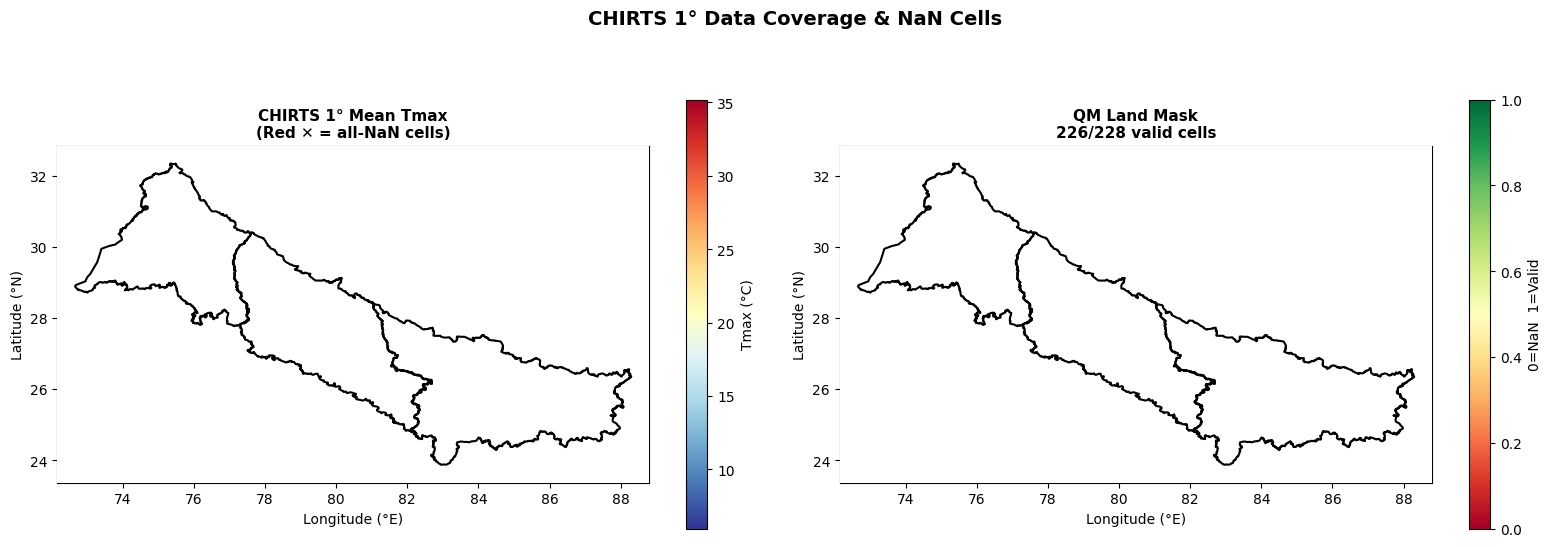

In [25]:
import geopandas as gpd
from shapely.geometry import box as shapely_box
from shapely.ops import unary_union

# Load study region boundary (reproject if needed)
study_gdf = gpd.read_file(f'{BASE}/target_shapefile')
if study_gdf.crs and study_gdf.crs.to_epsg() != 4326:
    study_gdf = study_gdf.to_crs(epsg=4326)

# Also load India boundary for reference
india_gdf = gpd.read_file(config.SHAPEFILE_PATH)
if india_gdf.crs and india_gdf.crs.to_epsg() != 4326:
    india_gdf = india_gdf.to_crs(epsg=4326)

# Study region bounds for axis limits
sb = study_gdf.total_bounds  # [minx, miny, maxx, maxy]
pad = 0.5

def mask_outside(ax, gdf):
    """Fill everything outside the boundary with white."""
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    rect = shapely_box(xlim[0]-2, ylim[0]-2, xlim[1]+2, ylim[1]+2)
    region = unary_union(gdf.geometry)
    outside = rect.difference(region)
    if outside.is_empty:
        return
    if outside.geom_type == 'MultiPolygon':
        for geom in outside.geoms:
            ax.fill(*geom.exterior.coords.xy, color='white', zorder=4)
    elif outside.geom_type == 'Polygon':
        ax.fill(*outside.exterior.coords.xy, color='white', zorder=4)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

obs_mean = obs_1deg.mean('time').compute()

# Panel 1: Mean Tmax with NaN cells
im = axes[0].pcolormesh(obs_1deg.lon, obs_1deg.lat, obs_mean.values,
                         cmap='RdYlBu_r', shading='auto', zorder=1)
study_gdf.boundary.plot(ax=axes[0], color='black', linewidth=1.5, zorder=5)
plt.colorbar(im, ax=axes[0], shrink=0.8, label='Tmax (°C)')

# Mark NaN cells
all_nan = np.all(np.isnan(obs_1deg.values), axis=0)
for li, lj in zip(*np.where(all_nan)):
    axes[0].plot(float(obs_1deg.lon[lj]), float(obs_1deg.lat[li]),
                 'rx', markersize=14, markeredgewidth=3, zorder=10)

axes[0].set_xlim(sb[0]-pad, sb[2]+pad)
axes[0].set_ylim(sb[1]-pad, sb[3]+pad)
mask_outside(axes[0], study_gdf)
axes[0].set_title('CHIRTS 1° Mean Tmax\n(Red ✕ = all-NaN cells)',
                   fontsize=11, fontweight='bold')
axes[0].set_xlabel('Longitude (°E)'); axes[0].set_ylabel('Latitude (°N)')
axes[0].set_aspect('equal')

# Panel 2: Land mask
land = (~all_nan).astype(float)
im2 = axes[1].pcolormesh(obs_1deg.lon, obs_1deg.lat, land,
                          cmap='RdYlGn', vmin=0, vmax=1, shading='auto', zorder=1)
study_gdf.boundary.plot(ax=axes[1], color='black', linewidth=1.5, zorder=5)
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='0=NaN  1=Valid')

axes[1].set_xlim(sb[0]-pad, sb[2]+pad)
axes[1].set_ylim(sb[1]-pad, sb[3]+pad)
mask_outside(axes[1], study_gdf)
axes[1].set_title(f'QM Land Mask\n{int((~all_nan).sum())}/{all_nan.size} valid cells',
                   fontsize=11, fontweight='bold')
axes[1].set_xlabel('Longitude (°E)'); axes[1].set_ylabel('Latitude (°N)')
axes[1].set_aspect('equal')

fig.suptitle('CHIRTS 1° Data Coverage & NaN Cells', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

In [26]:
import regionmask

study_gdf = gpd.read_file(f'{BASE}/target_shapefile')
if study_gdf.crs and study_gdf.crs.to_epsg() != 4326:
    study_gdf = study_gdf.to_crs(epsg=4326)

region = regionmask.from_geopandas(study_gdf)
rmask = region.mask(obs_1deg.lon, obs_1deg.lat)
inside_region = ~np.isnan(rmask).values
has_data = ~np.all(np.isnan(obs_1deg.values), axis=0)
land_mask = inside_region & has_data

print(f"Inside study region: {inside_region.sum()}")
print(f"Has CHIRTS data:     {has_data.sum()}")
print(f"Land cells for QM:   {land_mask.sum()}")

obs_1deg = obs_1deg.where(land_mask)
gcm_1deg = gcm_1deg.where(land_mask)

Inside study region: 38
Has CHIRTS data:     226
Land cells for QM:   38


In [27]:
def compute_monthly_running_avg(da_daily, window_years=9):
    """Per cell × month: N-year running avg of monthly means → daily."""
    monthly = da_daily.resample(time='1MS').mean()
    vals = monthly.values
    months_arr = monthly.time.dt.month.values
    smoothed = np.full_like(vals, np.nan)
    pad = window_years // 2

    for mon in range(1, 13):
        mask = months_arr == mon
        mv = vals[mask]
        ny = mv.shape[0]
        if ny == 0: continue
        if ny < window_years:
            smoothed[mask] = np.nanmean(mv, axis=0, keepdims=True)
            continue
        padded = np.pad(mv, ((pad, pad), (0,0), (0,0)), mode='edge')
        # Prepend zero row for correct cumsum windowing
        cs = np.nancumsum(padded, axis=0)
        cs = np.concatenate([np.zeros_like(cs[:1]), cs], axis=0)
        vc = np.nancumsum((~np.isnan(padded)).astype(np.float32), axis=0)
        vc = np.concatenate([np.zeros_like(vc[:1]), vc], axis=0)
        rs = cs[window_years:] - cs[:-window_years]
        rc = vc[window_years:] - vc[:-window_years]
        with np.errstate(invalid='ignore'):
            rm = np.where(rc > 0, rs / rc, np.nan)
        smoothed[mask] = rm[:ny]

    # Map monthly → daily
    dy = da_daily.time.dt.year.values
    dm = da_daily.time.dt.month.values
    result = np.full_like(da_daily.values, np.nan)
    sy = monthly.time.dt.year.values
    sm = monthly.time.dt.month.values
    lookup = {(int(y), int(m)): i for i, (y, m) in enumerate(zip(sy, sm))}
    for (y, m), idx in lookup.items():
        dmask = (dy == y) & (dm == m)
        if dmask.any():
            result[dmask] = smoothed[idx]
    return da_daily.copy(data=result)


print("=" * 65)
print("STEP 1: DETRENDING (9-year running average)")
print("=" * 65)

ckpt1_dir = config.WORK_DIR
ckpt1_files = [os.path.join(ckpt1_dir, f) for f in
               ['s1_obs_anom.nc','s1_his_anom.nc','s1_obs_ra.nc','s1_his_ra.nc']]

if all(os.path.exists(f) for f in ckpt1_files):
    print("  Loading from checkpoint...")
    obs_anom = xr.open_dataarray(ckpt1_files[0]).load()
    his_anom = xr.open_dataarray(ckpt1_files[1]).load()
    obs_ra   = xr.open_dataarray(ckpt1_files[2]).load()
    his_ra   = xr.open_dataarray(ckpt1_files[3]).load()
else:
    t0 = timer.time()
    obs_ra = compute_monthly_running_avg(obs_1deg, config.RUNNING_AVG_WINDOW)
    his_ra = compute_monthly_running_avg(gcm_1deg, config.RUNNING_AVG_WINDOW)
    obs_anom = obs_1deg - obs_ra
    his_anom = gcm_1deg - his_ra
    print(f"  Done in {timer.time()-t0:.1f}s")

    # Sanity: monthly anomaly mean should be ~0
    for mon in range(1, 13):
        m = float(obs_anom.sel(time=obs_anom.time.dt.month == mon).mean())
        if abs(m) > 1.0:
            print(f"  ⚠️  Month {mon} obs anomaly mean={m:.2f} (expect ~0)")

    # Remove stale files before writing (prevents PermissionError on re-run)
    for f in ckpt1_files:
        if os.path.exists(f):
            os.remove(f)
    obs_anom.to_netcdf(ckpt1_files[0])
    his_anom.to_netcdf(ckpt1_files[1])
    obs_ra.to_netcdf(ckpt1_files[2])
    his_ra.to_netcdf(ckpt1_files[3])
    print(f"  Checkpoints saved.")

print("Step 1 complete.")

STEP 1: DETRENDING (9-year running average)
  Done in 0.3s
  Checkpoints saved.
Step 1 complete.


In [28]:
print("=" * 65)
print("STEP 2: BIAS CORRECTION (QM, \u00b115-day window)")
print("=" * 65)

ckpt2 = os.path.join(config.WORK_DIR, 'step2_bc_his.nc')
if os.path.exists(ckpt2):
    print("  Loading from checkpoint...")
    bc_his = xr.open_dataarray(ckpt2).load()
else:
    obs_doy = obs_anom.time.dt.dayofyear.values
    his_doy = his_anom.time.dt.dayofyear.values

    obs_vals = obs_anom.values
    his_vals = his_anom.values
    bc_vals = np.full_like(his_vals, np.nan)
    nlat, nlon = obs_vals.shape[1], obs_vals.shape[2]
    dw = config.QM_DAY_WINDOW

    n_land = int(land_mask.sum())
    print(f"  366 DOYs \u00d7 {n_land} land cells (vectorized)")
    t0 = timer.time()
    skipped_doys = 0

    for doy in range(1, 367):
        if doy % 50 == 0:
            print(f"    DOY {doy}/366 ({timer.time()-t0:.0f}s)")

        # \u00b115 day window with year-boundary wrapping
        window_doys = set()
        for d in range(doy - dw, doy + dw + 1):
            if d < 1:
                window_doys.add(d + 365)
                if d + 365 == 365:
                    window_doys.add(366)
            elif d > 366:
                window_doys.add(d - 366)
            else:
                window_doys.add(d)
        w_arr = np.array(sorted(window_doys))

        # Pool
        obs_pool = obs_vals[np.isin(obs_doy, w_arr)]
        his_pool = his_vals[np.isin(his_doy, w_arr)]

        if obs_pool.shape[0] < 10 or his_pool.shape[0] < 10:
            skipped_doys += 1
            continue

        # Sort (NaN goes to end)
        obs_sorted = np.sort(obs_pool, axis=0)
        his_sorted = np.sort(his_pool, axis=0)
        obs_nvalid = (~np.isnan(obs_pool)).sum(axis=0).astype(np.float32)
        his_nvalid = (~np.isnan(his_pool)).sum(axis=0).astype(np.float32)
        valid_his_mask = ~np.isnan(his_sorted)  # (n_pool, nlat, nlon)

        # QM each year at this DOY
        doy_mask = his_doy == doy
        if not doy_mask.any():
            continue

        his_at_doy = his_vals[doy_mask]
        global_indices = np.where(doy_mask)[0]

        for t in range(his_at_doy.shape[0]):
            v = his_at_doy[t]  # (nlat, nlon)

            # VECTORIZED quantile position
            below = (his_sorted <= v[np.newaxis, :, :]) & valid_his_mask
            count_below = below.sum(axis=0).astype(np.float32)

            with np.errstate(invalid='ignore'):
                qpos = np.where(his_nvalid > 0, count_below / his_nvalid, np.nan)
            qpos = np.clip(qpos, 0.0, 1.0)

            # Map to obs quantile
            idx_f = qpos * (obs_nvalid - 1)
            idx_f = np.clip(idx_f, 0, None)
            i_lo = np.floor(idx_f).astype(int)
            i_hi = np.minimum(i_lo + 1, (obs_nvalid - 1).astype(int))
            i_hi = np.clip(i_hi, 0, obs_pool.shape[0] - 1)
            i_lo = np.clip(i_lo, 0, obs_pool.shape[0] - 1)
            frac = idx_f - i_lo

            li, lj = np.meshgrid(np.arange(nlat), np.arange(nlon), indexing='ij')
            bc_v = obs_sorted[i_lo, li, lj] * (1 - frac) + \
                   obs_sorted[i_hi, li, lj] * frac

            bc_v[~land_mask] = np.nan
            bc_v[np.isnan(v)] = np.nan
            bc_vals[global_indices[t]] = bc_v

    print(f"  QM done in {timer.time()-t0:.1f}s  (skipped {skipped_doys} DOYs)")

    # Restore trend: add obs running average
    # Use .values to avoid xarray time-coord alignment issues
    assert bc_vals.shape == obs_ra.values.shape, \
        f"Shape mismatch: bc={bc_vals.shape}, obs_ra={obs_ra.values.shape}"
    bc_his = his_anom.copy(data=bc_vals + obs_ra.values)

    # Check for introduced NaN
    new_nan = np.isnan(bc_his.values) & ~np.isnan(his_anom.values) & land_mask
    if new_nan.any():
        print(f"  \u26a0\ufe0f  QM introduced {int(new_nan.sum())} new NaN on land")

    # Remove stale file before writing (prevents PermissionError on re-run)
    if os.path.exists(ckpt2):
        os.remove(ckpt2)
    bc_his.to_netcdf(ckpt2)
    print(f"  Checkpoint saved: {ckpt2}")

print("Step 2 complete.")

STEP 2: BIAS CORRECTION (QM, ±15-day window)
  366 DOYs × 38 land cells (vectorized)
    DOY 50/366 (1s)
    DOY 100/366 (3s)
    DOY 150/366 (4s)
    DOY 200/366 (5s)
    DOY 250/366 (7s)
    DOY 300/366 (8s)
    DOY 350/366 (9s)
  QM done in 9.7s  (skipped 0 DOYs)
  Checkpoint saved: /kaggle/working/bcsd_checkpoints/step2_bc_his.nc
Step 2 complete.


In [29]:
print("=" * 65)
print("STEP 3: SPATIAL DISAGGREGATION (IDW)")
print("=" * 65)

# Ensure bc_his is fully in memory (not lazy from checkpoint)
if not isinstance(bc_his.values, np.ndarray):
    bc_his = bc_his.load()

# Daily climatologies
print("  Computing daily climatologies...")
obs_clim_fine = obs_fine.groupby('time.dayofyear').mean('time')
obs_clim_coarse = obs_1deg.groupby('time.dayofyear').mean('time')
avail_doys_fine = set(obs_clim_fine.dayofyear.values.tolist())
avail_doys_coarse = set(obs_clim_coarse.dayofyear.values.tolist())

# Build IDW weights (once)
print("  Building IDW weights...")
src_lon_g, src_lat_g = np.meshgrid(bc_his.lon.values, bc_his.lat.values)
src_pts = np.column_stack([src_lat_g.ravel(), src_lon_g.ravel()])
tgt_lon_g, tgt_lat_g = np.meshgrid(obs_fine.lon.values, obs_fine.lat.values)
tgt_pts = np.column_stack([tgt_lat_g.ravel(), tgt_lon_g.ravel()])
tree = cKDTree(src_pts)
dists, idw_idx = tree.query(tgt_pts, k=config.IDW_N_NEIGHBORS)
with np.errstate(divide='ignore', invalid='ignore'):
    inv_d = 1.0 / np.power(dists, config.IDW_POWER)
exact = dists == 0
if exact.any():
    inv_d[exact] = 1e30
    for r in np.where(exact.any(axis=1))[0]:
        inv_d[r, ~exact[r]] = 0
idw_wts = inv_d / inv_d.sum(axis=1, keepdims=True)

tgt_lats = obs_fine.lat.values
tgt_lons = obs_fine.lon.values

# Process year by year
bc_years = bc_his.time.dt.year.values
bc_doys = bc_his.time.dt.dayofyear.values
unique_years = np.unique(bc_years)
output_files = []
t0 = timer.time()

for year in unique_years:
    ckpt_yr = os.path.join(config.WORK_DIR, f'step3_sd_{year}.nc')
    if os.path.exists(ckpt_yr):
        output_files.append(ckpt_yr)
        continue

    ymask = bc_years == year
    bc_yr = bc_his.isel(time=ymask)
    doys = bc_doys[ymask]

    # Scale factors at 1\u00b0
    sf = np.full_like(bc_yr.values, np.nan)
    for t, d in enumerate(doys):
        sd = d if d in avail_doys_coarse else 365
        sf[t] = bc_yr.values[t] - obs_clim_coarse.sel(dayofyear=sd).values

    # IDW interpolate
    nt = sf.shape[0]
    src_flat = sf.reshape(nt, -1)
    nv = src_flat[:, idw_idx]  # (nt, n_tgt, k)
    valid = ~np.isnan(nv)
    w = np.broadcast_to(idw_wts[np.newaxis], nv.shape)
    wm = np.where(valid, w, 0)
    ws = wm.sum(axis=2, keepdims=True)
    with np.errstate(invalid='ignore'):
        sf_fine = np.where(ws.squeeze(2) > 0,
                           (np.nan_to_num(nv, 0) * wm).sum(axis=2) / ws.squeeze(2),
                           np.nan)
    sf_fine = sf_fine.reshape(nt, len(tgt_lats), len(tgt_lons))

    # Add fine climatology
    result = np.full_like(sf_fine, np.nan, dtype=np.float32)
    for t, d in enumerate(doys):
        sd = d if d in avail_doys_fine else 365
        result[t] = sf_fine[t] + obs_clim_fine.sel(dayofyear=sd).values

    xr.Dataset({'tmax': xr.DataArray(
        result, dims=['time','lat','lon'],
        coords={'time': bc_yr.time.values, 'lat': tgt_lats, 'lon': tgt_lons}
    )}).to_netcdf(ckpt_yr)
    output_files.append(ckpt_yr)
    print(f"    {year}: {nt} days ({timer.time()-t0:.0f}s total)")

print(f"\n\u2705 PIPELINE COMPLETE \u2014 {len(output_files)} yearly files")

STEP 3: SPATIAL DISAGGREGATION (IDW)
  Computing daily climatologies...
  Building IDW weights...
    1983: 365 days (3s total)
    1984: 366 days (6s total)
    1985: 365 days (8s total)
    1986: 365 days (11s total)
    1987: 365 days (13s total)
    1988: 366 days (15s total)
    1989: 365 days (18s total)
    1990: 365 days (20s total)
    1991: 365 days (23s total)
    1992: 366 days (25s total)
    1993: 365 days (28s total)
    1994: 365 days (30s total)
    1995: 365 days (33s total)
    1996: 366 days (35s total)
    1997: 365 days (38s total)
    1998: 365 days (40s total)
    1999: 365 days (43s total)
    2000: 366 days (46s total)
    2001: 365 days (55s total)
    2002: 365 days (58s total)
    2003: 365 days (61s total)
    2004: 366 days (63s total)
    2005: 365 days (66s total)
    2006: 365 days (68s total)
    2007: 365 days (71s total)
    2008: 366 days (74s total)
    2009: 365 days (76s total)
    2010: 365 days (79s total)
    2011: 365 days (82s total)
    20

## Evaluation — 8 paper-style figures (Xu & Wang 2019 / Tran-Anh 2023)

Uses pipeline variables: `obs_fine, obs_1deg, gcm_1deg, bc_his, config, land_mask`.
Reads the `step3_sd_<year>.nc` files written above and produces:
  Fig 1 Mean climatology · Fig 2 Seasonal bias · Fig 3 Std dev · Fig 4 RMSE (3-stage)
  Fig 5 Seasonal-cycle corr · Fig 6 Annual cycle at points · Fig 7 Box plots · Fig 8 Added value

In [30]:
EVAL_START, EVAL_END = 1983, 2014
FIG_DIR = os.path.join(config.WORK_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)
DPI = 250

# \u2500\u2500 Load BCSD output (step3 yearly files) \u2500\u2500
bcsd_files = sorted(glob.glob(os.path.join(config.WORK_DIR, 'step3_sd_*.nc')))
bcsd_files = [f for f in bcsd_files
              if EVAL_START <= int(os.path.basename(f).split('_')[-1][:4]) <= EVAL_END]
bcsd = xr.open_mfdataset(bcsd_files, combine='by_coords',
                         chunks={'time': 365})['tmax']

# \u2500\u2500 Normalize timestamps to midnight for clean alignment \u2500\u2500
def norm_time(da):
    return da.assign_coords(time=da.time.values.astype('datetime64[D]'))

bcsd  = norm_time(bcsd.sel(time=slice(f'{EVAL_START}', f'{EVAL_END}')))
obs_f = norm_time(obs_fine.sel(time=slice(f'{EVAL_START}', f'{EVAL_END}')))
obs_c = norm_time(obs_1deg.sel(time=slice(f'{EVAL_START}', f'{EVAL_END}')))
gcm_c = norm_time(gcm_1deg.sel(time=slice(f'{EVAL_START}', f'{EVAL_END}')))

# \u2500\u2500 Load QM-corrected GCM at 1\u00b0 (Step-2 checkpoint, else in-memory bc_his) \u2500\u2500
bc_1deg_path = os.path.join(config.WORK_DIR, 'step2_bc_his.nc')
if os.path.exists(bc_1deg_path):
    bc_c = norm_time(xr.open_dataarray(bc_1deg_path).load().sel(
        time=slice(f'{EVAL_START}', f'{EVAL_END}')))
else:
    bc_c = norm_time(bc_his.sel(time=slice(f'{EVAL_START}', f'{EVAL_END}')))

# \u2500\u2500 India boundary \u2500\u2500
india_gdf = None
try:
    import geopandas as gpd
    india_gdf = gpd.read_file(config.SHAPEFILE_PATH)
    print(f"Boundary: {os.path.basename(config.SHAPEFILE_PATH)}")
except Exception as e:
    print(f"No boundary: {e}")

# \u2500\u2500 Extents \u2500\u2500
LON_MIN, LON_MAX = float(obs_f.lon.min()), float(obs_f.lon.max())
LAT_MIN, LAT_MAX = float(obs_f.lat.min()), float(obs_f.lat.max())
LON_MIN_C, LON_MAX_C = float(obs_c.lon.min()), float(obs_c.lon.max())
LAT_MIN_C, LAT_MAX_C = float(obs_c.lat.min()), float(obs_c.lat.max())

print(f"Eval: {EVAL_START}\u2013{EVAL_END}")
print(f"bcsd={bcsd.shape}, obs_f={obs_f.shape}, gcm_c={gcm_c.shape}")


# \u2500\u2500 Master plotting function (single definition for all figures) \u2500\u2500
def plot_india(ax, da2d, title, cmap, vmin, vmax, cbar_label,
               center=None, extend='both', coarse=False):
    """Plot a 2D field as an India map, paper style. coarse=True \u2192 1\u00b0 extents."""
    if center is not None:
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)
        im = ax.pcolormesh(da2d.lon, da2d.lat, da2d.values,
                           cmap=cmap, norm=norm, shading='auto')
    else:
        im = ax.pcolormesh(da2d.lon, da2d.lat, da2d.values,
                           cmap=cmap, vmin=vmin, vmax=vmax, shading='auto')
    if india_gdf is not None:
        india_gdf.boundary.plot(ax=ax, color='k', linewidth=0.7, zorder=5)
    if coarse:
        ax.set_xlim(LON_MIN_C - 0.5, LON_MAX_C + 0.5)
        ax.set_ylim(LAT_MIN_C - 0.5, LAT_MAX_C + 0.5)
    else:
        ax.set_xlim(LON_MIN, LON_MAX)
        ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_title(title, fontsize=9, fontweight='bold', pad=4)
    ax.set_xlabel('\u00b0E', fontsize=7)
    ax.set_ylabel('\u00b0N', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_aspect('equal')
    cb = plt.colorbar(im, ax=ax, shrink=0.82, extend=extend, pad=0.02, aspect=25)
    cb.set_label(cbar_label, fontsize=7)
    cb.ax.tick_params(labelsize=6)
    # Domain-mean stats in corner
    mean_val = float(np.nanmean(da2d.values))
    max_val = float(np.nanmax(da2d.values))
    min_val = float(np.nanmin(da2d.values))
    ax.text(0.02, 0.02,
            f'Avg: {mean_val:.2f}\nMax: {max_val:.2f}\nMin: {min_val:.2f}',
            transform=ax.transAxes, fontsize=5.5, verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      alpha=0.8, edgecolor='gray', linewidth=0.5))
    return im


# \u2500\u2500 Shared helpers used by multiple figures (defined once) \u2500\u2500
def seasonal_mean(da, months):
    if months is None:
        return da.mean('time').compute()
    return da.sel(time=da.time.dt.month.isin(months)).mean('time').compute()

def daily_anom(da):
    return da.groupby('time.dayofyear') - da.groupby('time.dayofyear').mean('time')

def seasonal_cycle_corr(model, obs):
    """Per-cell correlation of the 12-month climatological cycle."""
    m_ac = model.groupby('time.month').mean('time')  # (12, lat, lon)
    o_ac = obs.groupby('time.month').mean('time')
    m_vals = m_ac.values
    o_vals = o_ac.values
    m_mean = np.nanmean(m_vals, axis=0, keepdims=True)
    o_mean = np.nanmean(o_vals, axis=0, keepdims=True)
    m_dev = m_vals - m_mean
    o_dev = o_vals - o_mean
    num = np.nansum(m_dev * o_dev, axis=0)
    den = np.sqrt(np.nansum(m_dev**2, axis=0) * np.nansum(o_dev**2, axis=0))
    with np.errstate(invalid='ignore'):
        r = np.where(den > 0, num / den, np.nan)
    return xr.DataArray(r, dims=['lat','lon'],
                        coords={'lat': model.lat, 'lon': model.lon})

SEASONS = {'Annual': None, 'DJF': [12,1,2], 'MAM': [3,4,5],
           'JJA': [6,7,8], 'SON': [9,10,11]}

Boundary: target (1).shp
Eval: 1983–2014
bcsd=(11688, 190, 333), obs_f=(11688, 190, 333), gcm_c=(11688, 12, 19)


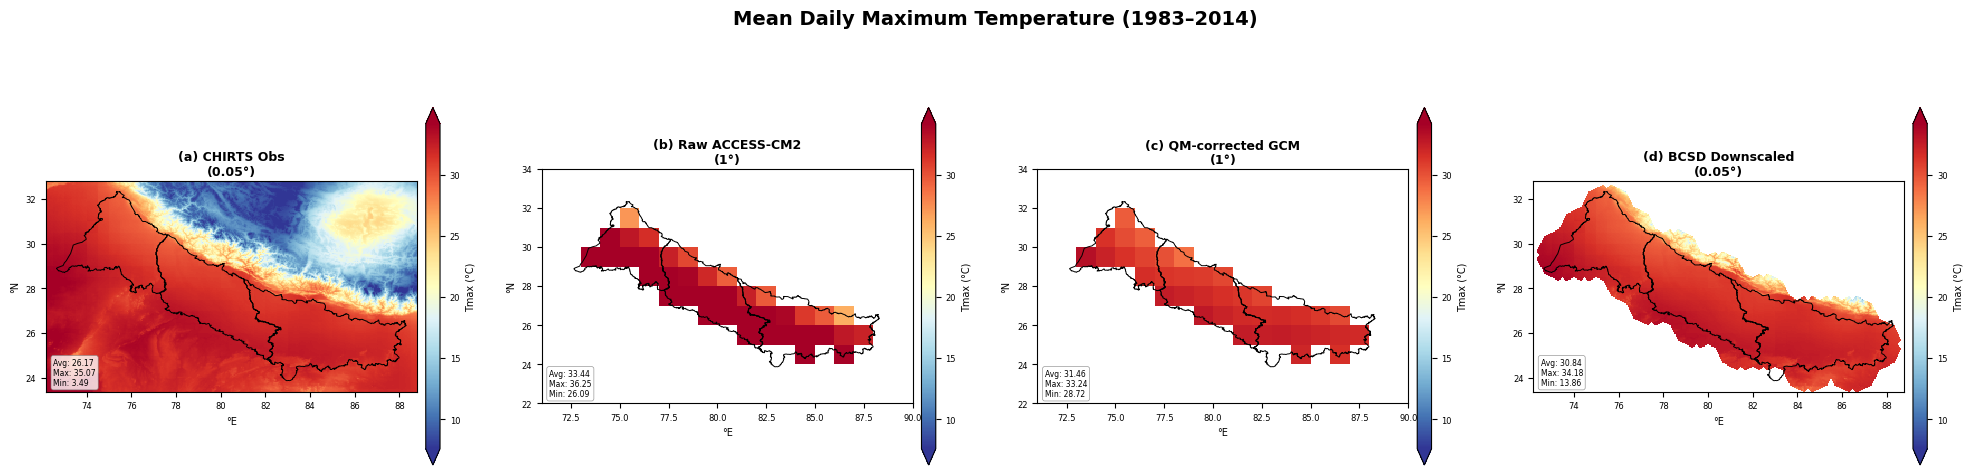

Fig 1 saved.


In [31]:
obs_f_mean = obs_f.mean('time').compute()
gcm_c_mean = gcm_c.mean('time').compute()
bcsd_mean  = bcsd.mean('time').compute()
bc_c_mean  = bc_c.mean('time').compute()

vmin = float(np.nanpercentile(obs_f_mean, 1))
vmax = float(np.nanpercentile(obs_f_mean, 99))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
plot_india(axes[0], obs_f_mean, f'(a) CHIRTS Obs\n(0.05°)',
           'RdYlBu_r', vmin, vmax, 'Tmax (°C)')
plot_india(axes[1], gcm_c_mean, f'(b) Raw ACCESS-CM2\n(1°)',
           'RdYlBu_r', vmin, vmax, 'Tmax (°C)', coarse=True)
plot_india(axes[2], bc_c_mean, f'(c) QM-corrected GCM\n(1°)',
           'RdYlBu_r', vmin, vmax, 'Tmax (°C)', coarse=True)

plot_india(axes[3], bcsd_mean, f'(d) BCSD Downscaled\n(0.05°)',
           'RdYlBu_r', vmin, vmax, 'Tmax (°C)')
fig.suptitle(f'Mean Daily Maximum Temperature ({EVAL_START}–{EVAL_END})',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig1_mean_climatology.png', dpi=DPI,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Fig 1 saved.")

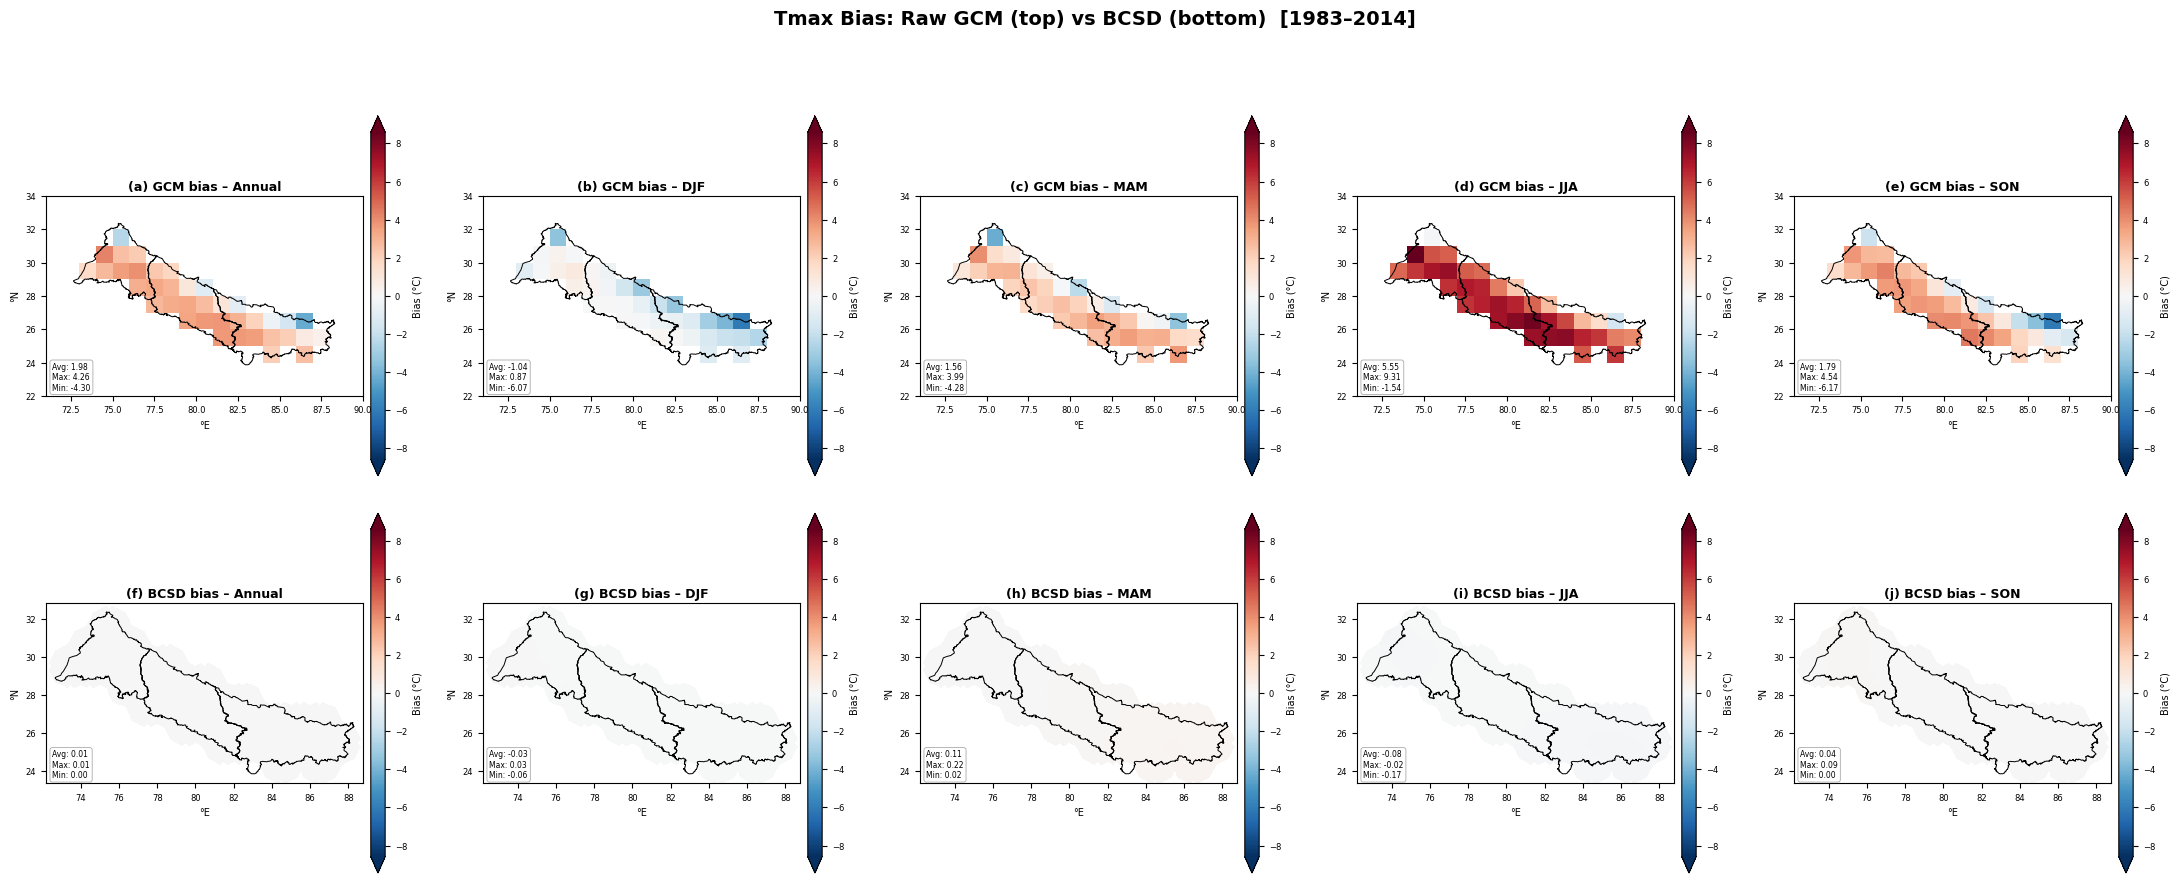

Fig 2 saved.


In [32]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))

# Find global bias limits
all_biases = []
for sname, smons in SEASONS.items():
    gcm_s = seasonal_mean(gcm_c, smons)
    obs_s = seasonal_mean(obs_c, smons)
    all_biases.append(float(np.nanpercentile(np.abs(gcm_s - obs_s), 98)))
vlim = max(max(all_biases), 1.0)

for col, (sname, smons) in enumerate(SEASONS.items()):
    # Row 0: Raw GCM bias (1°)
    gcm_s = seasonal_mean(gcm_c, smons)
    obs_cs = seasonal_mean(obs_c, smons)
    gcm_bias_s = gcm_s - obs_cs
    plot_india(axes[0, col], gcm_bias_s,
               f'({chr(97+col)}) GCM bias – {sname}',
               'RdBu_r', -vlim, vlim, 'Bias (°C)', center=0, coarse=True)

    # Row 1: BCSD bias (0.05°)
    bcsd_s = seasonal_mean(bcsd, smons)
    obs_fs = seasonal_mean(obs_f, smons)
    bcsd_bias_s = bcsd_s - obs_fs
    plot_india(axes[1, col], bcsd_bias_s,
               f'({chr(102+col)}) BCSD bias – {sname}',
               'RdBu_r', -vlim, vlim, 'Bias (°C)', center=0)

fig.suptitle(f'Tmax Bias: Raw GCM (top) vs BCSD (bottom)  [{EVAL_START}–{EVAL_END}]',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig2_seasonal_bias.png', dpi=DPI,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Fig 2 saved.")

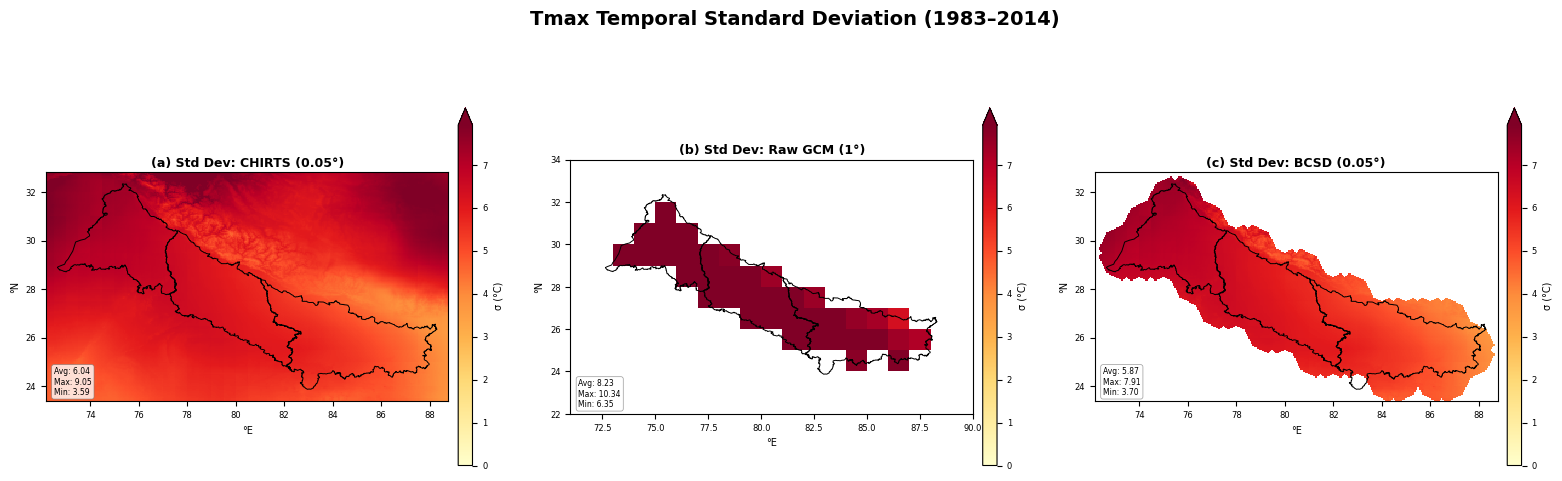

Fig 3 saved.


In [33]:
obs_f_std = obs_f.std('time').compute()
gcm_c_std = gcm_c.std('time').compute()
bcsd_std  = bcsd.std('time').compute()

vmax_std = float(np.nanpercentile(obs_f_std, 98))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_india(axes[0], obs_f_std, '(a) Std Dev: CHIRTS (0.05°)',
           'YlOrRd', 0, vmax_std, 'σ (°C)', extend='max')
plot_india(axes[1], gcm_c_std, '(b) Std Dev: Raw GCM (1°)',
           'YlOrRd', 0, vmax_std, 'σ (°C)', extend='max', coarse=True)
plot_india(axes[2], bcsd_std, '(c) Std Dev: BCSD (0.05°)',
           'YlOrRd', 0, vmax_std, 'σ (°C)', extend='max')
fig.suptitle(f'Tmax Temporal Standard Deviation ({EVAL_START}–{EVAL_END})',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig3_std_dev.png', dpi=DPI,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Fig 3 saved.")

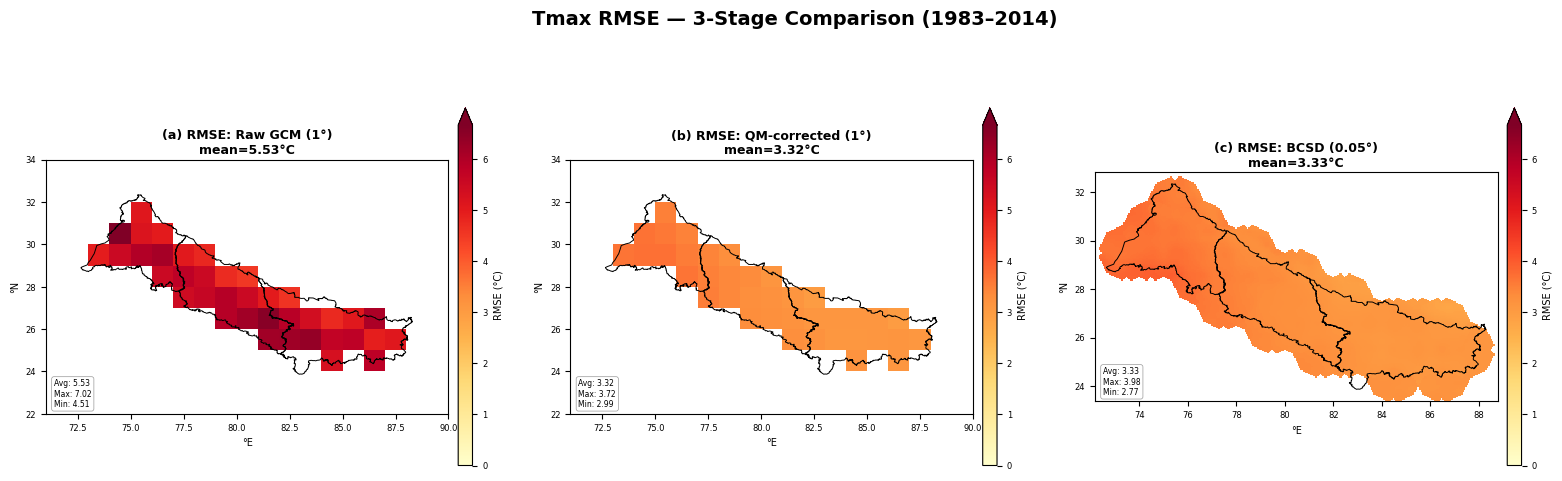

Fig 4 saved.


In [35]:
gcm_rmse  = np.sqrt(((gcm_c - obs_c)**2).mean('time')).compute()
bc_rmse   = np.sqrt(((bc_c - obs_c)**2).mean('time')).compute()
bcsd_rmse = np.sqrt(((bcsd - obs_f)**2).mean('time')).compute()

vmax_r = max(float(np.nanpercentile(gcm_rmse, 98)), 1.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_india(axes[0], gcm_rmse, f'(a) RMSE: Raw GCM (1°)\nmean={float(gcm_rmse.mean()):.2f}°C',
           'YlOrRd', 0, vmax_r, 'RMSE (°C)', extend='max', coarse=True)
plot_india(axes[1], bc_rmse, f'(b) RMSE: QM-corrected (1°)\nmean={float(bc_rmse.mean()):.2f}°C',
           'YlOrRd', 0, vmax_r, 'RMSE (°C)', extend='max', coarse=True)
plot_india(axes[2], bcsd_rmse, f'(c) RMSE: BCSD (0.05°)\nmean={float(bcsd_rmse.mean()):.2f}°C',
           'YlOrRd', 0, vmax_r, 'RMSE (°C)', extend='max')
fig.suptitle(f'Tmax RMSE — 3-Stage Comparison ({EVAL_START}–{EVAL_END})',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig4_rmse_3stage.png', dpi=DPI,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Fig 4 saved.")

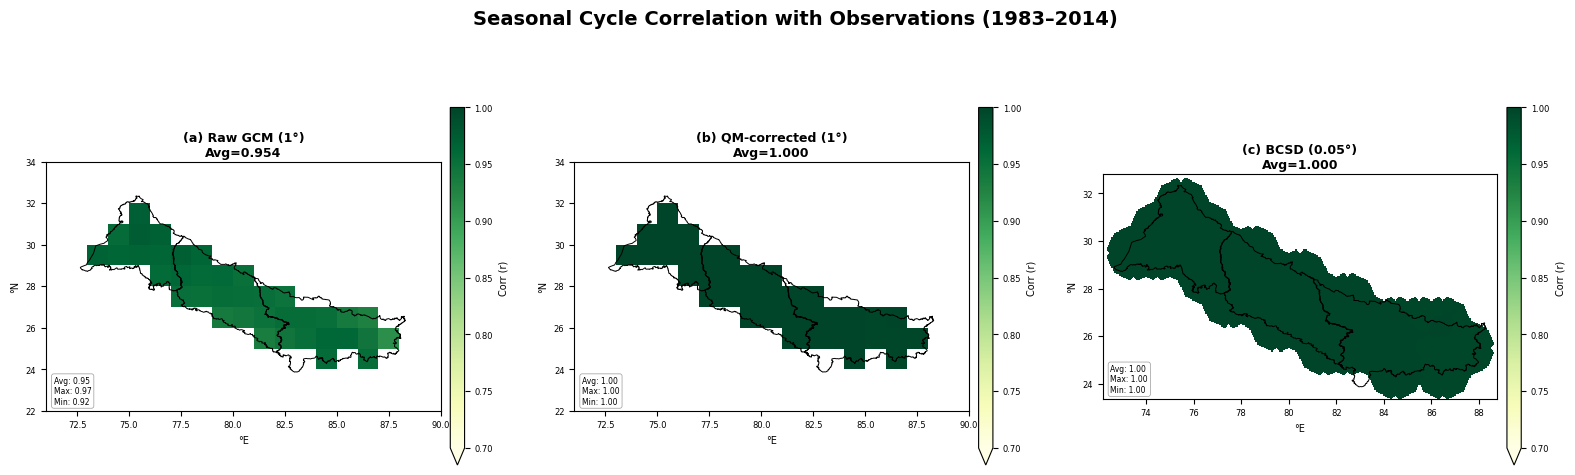

Fig 5 saved.


In [37]:
# NOTE: gcm_sc_r / bc_sc_r / bcsd_sc_r are reused by the summary table in Eval Cell 8,
# so this cell MUST run before Fig 8.
gcm_sc_r  = seasonal_cycle_corr(gcm_c, obs_c)
bc_sc_r   = seasonal_cycle_corr(bc_c, obs_c)
bcsd_sc_r = seasonal_cycle_corr(bcsd, obs_f)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_india(axes[0], gcm_sc_r,
           f'(a) Raw GCM (1°)\nAvg={float(np.nanmean(gcm_sc_r)):.3f}',
           'YlGn', 0.7, 1.0, 'Corr (r)', extend='min', coarse=True)
plot_india(axes[1], bc_sc_r,
           f'(b) QM-corrected (1°)\nAvg={float(np.nanmean(bc_sc_r)):.3f}',
           'YlGn', 0.7, 1.0, 'Corr (r)', extend='min', coarse=True)
plot_india(axes[2], bcsd_sc_r,
           f'(c) BCSD (0.05°)\nAvg={float(np.nanmean(bcsd_sc_r)):.3f}',
           'YlGn', 0.7, 1.0, 'Corr (r)', extend='min')
fig.suptitle(f'Seasonal Cycle Correlation with Observations ({EVAL_START}–{EVAL_END})',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig5_seasonal_corr.png', dpi=DPI,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Fig 5 saved.")

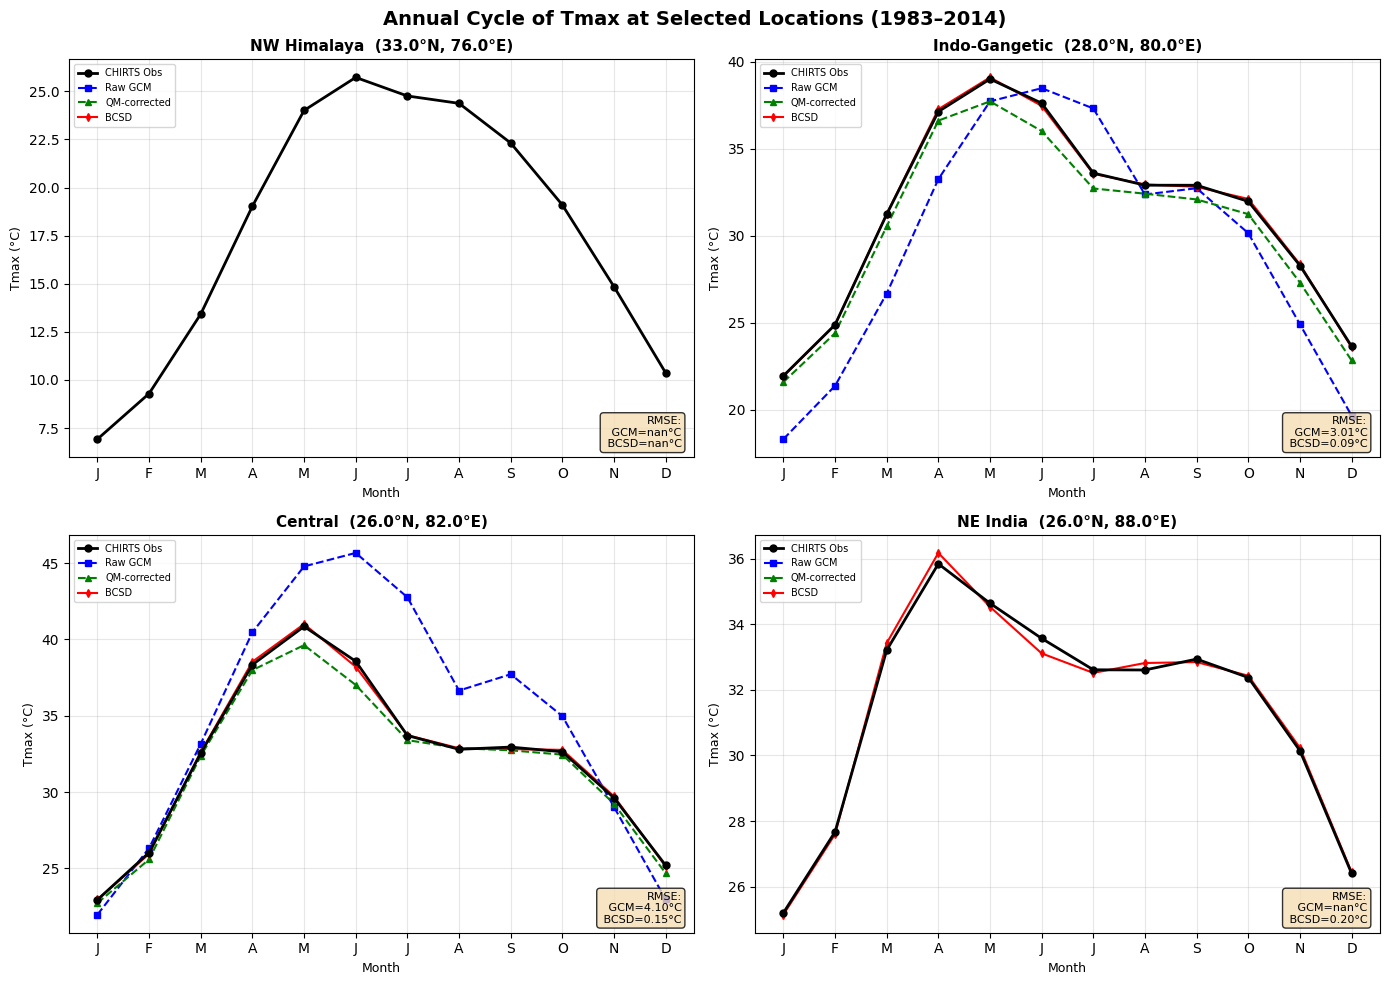

Fig 6 saved.


In [38]:
sample_points = {
    'NW Himalaya':   (33.0, 76.0),
    'Indo-Gangetic': (28.0, 80.0),
    'Central':       (26.0, 82.0),
    'NE India':      (26.0, 88.0),
}

months = np.arange(1, 13)
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, (lat, lon)) in zip(axes.flat, sample_points.items()):
    obs_pt = obs_f.sel(lat=lat, lon=lon, method='nearest')
    obs_mc = obs_pt.groupby('time.month').mean('time').values

    gcm_pt = gcm_c.sel(lat=lat, lon=lon, method='nearest')
    gcm_mc = gcm_pt.groupby('time.month').mean('time').values

    bc_pt = bc_c.sel(lat=lat, lon=lon, method='nearest')
    bc_mc = bc_pt.groupby('time.month').mean('time').values

    bcsd_pt = bcsd.sel(lat=lat, lon=lon, method='nearest')
    bcsd_mc = bcsd_pt.groupby('time.month').mean('time').compute().values

    ax.plot(months, obs_mc, 'k-o', linewidth=2, markersize=5, label='CHIRTS Obs', zorder=5)
    ax.plot(months, gcm_mc, 'b--s', linewidth=1.5, markersize=4, label='Raw GCM')
    ax.plot(months, bc_mc, 'g--^', linewidth=1.5, markersize=4, label='QM-corrected')
    ax.plot(months, bcsd_mc, 'r-d', linewidth=1.5, markersize=4, label='BCSD')

    rmse_gcm = np.sqrt(np.mean((gcm_mc - obs_mc)**2))
    rmse_bcsd = np.sqrt(np.mean((bcsd_mc - obs_mc)**2))
    ax.text(0.98, 0.02,
            f'RMSE:\n GCM={rmse_gcm:.2f}°C\n BCSD={rmse_bcsd:.2f}°C',
            transform=ax.transAxes, fontsize=8, ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    ax.set_title(f'{name}  ({lat}°N, {lon}°E)', fontsize=11, fontweight='bold')
    ax.set_xticks(months)
    ax.set_xticklabels(month_labels)
    ax.set_ylabel('Tmax (°C)', fontsize=9)
    ax.set_xlabel('Month', fontsize=9)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Annual Cycle of Tmax at Selected Locations ({EVAL_START}–{EVAL_END})',
             fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig6_annual_cycle.png', dpi=DPI,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Fig 6 saved.")

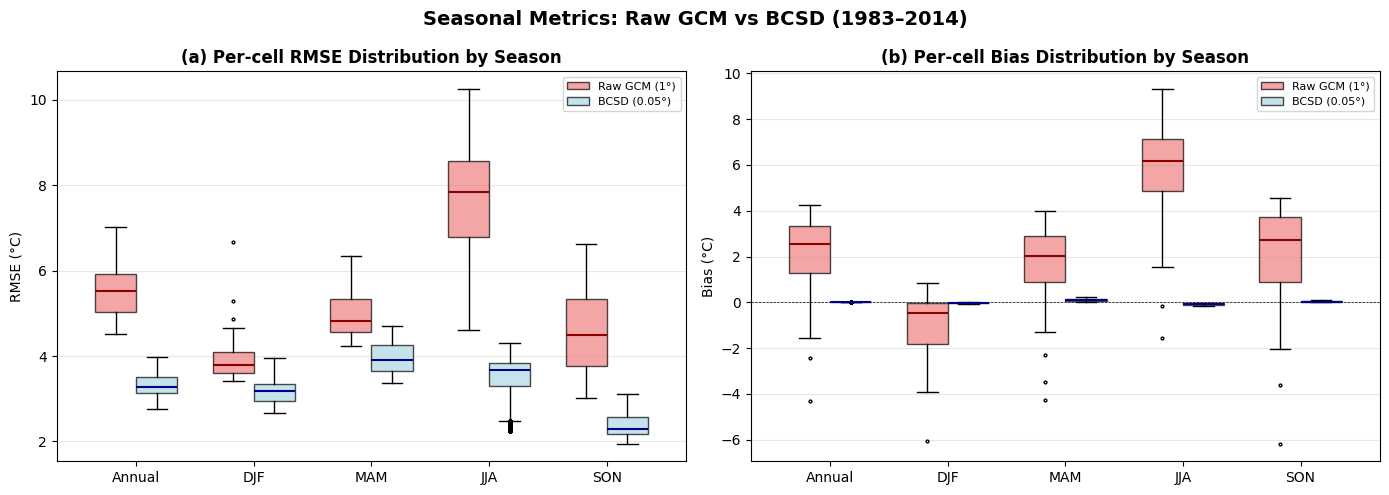

Fig 7 saved.


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_names = ['Annual', 'DJF', 'MAM', 'JJA', 'SON']
season_months = [None, [12,1,2], [3,4,5], [6,7,8], [9,10,11]]

gcm_rmse_box = []
bcsd_rmse_box = []
for smons in season_months:
    if smons is None:
        g = gcm_c; o_c = obs_c; b = bcsd; o_f = obs_f
    else:
        g = gcm_c.sel(time=gcm_c.time.dt.month.isin(smons))
        o_c = obs_c.sel(time=obs_c.time.dt.month.isin(smons))
        b = bcsd.sel(time=bcsd.time.dt.month.isin(smons))
        o_f = obs_f.sel(time=obs_f.time.dt.month.isin(smons))
    gcm_r_box = np.sqrt(((g - o_c)**2).mean('time')).compute().values.ravel()
    bcsd_r_box = np.sqrt(((b - o_f)**2).mean('time')).compute().values.ravel()
    gcm_rmse_box.append(gcm_r_box[~np.isnan(gcm_r_box)])
    bcsd_rmse_box.append(bcsd_r_box[~np.isnan(bcsd_r_box)])

positions = np.arange(len(season_names))
width = 0.35
bp1 = axes[0].boxplot(gcm_rmse_box, positions=positions - width/2,
                      widths=width, patch_artist=True,
                      boxprops=dict(facecolor='lightcoral', alpha=0.7),
                      medianprops=dict(color='darkred', linewidth=1.5),
                      flierprops=dict(markersize=2))
bp2 = axes[0].boxplot(bcsd_rmse_box, positions=positions + width/2,
                      widths=width, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', alpha=0.7),
                      medianprops=dict(color='darkblue', linewidth=1.5),
                      flierprops=dict(markersize=2))
axes[0].set_xticks(positions)
axes[0].set_xticklabels(season_names)
axes[0].set_ylabel('RMSE (°C)')
axes[0].set_title('(a) Per-cell RMSE Distribution by Season', fontweight='bold')
axes[0].legend([bp1['boxes'][0], bp2['boxes'][0]],
               ['Raw GCM (1°)', 'BCSD (0.05°)'], fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

gcm_bias_box = []
bcsd_bias_box = []
for smons in season_months:
    if smons is None:
        g = gcm_c; o_c = obs_c; b = bcsd; o_f = obs_f
    else:
        g = gcm_c.sel(time=gcm_c.time.dt.month.isin(smons))
        o_c = obs_c.sel(time=obs_c.time.dt.month.isin(smons))
        b = bcsd.sel(time=bcsd.time.dt.month.isin(smons))
        o_f = obs_f.sel(time=obs_f.time.dt.month.isin(smons))
    gb = (g.mean('time') - o_c.mean('time')).compute().values.ravel()
    bb = (b.mean('time') - o_f.mean('time')).compute().values.ravel()
    gcm_bias_box.append(gb[~np.isnan(gb)])
    bcsd_bias_box.append(bb[~np.isnan(bb)])

bp3 = axes[1].boxplot(gcm_bias_box, positions=positions - width/2,
                      widths=width, patch_artist=True,
                      boxprops=dict(facecolor='lightcoral', alpha=0.7),
                      medianprops=dict(color='darkred', linewidth=1.5),
                      flierprops=dict(markersize=2))
bp4 = axes[1].boxplot(bcsd_bias_box, positions=positions + width/2,
                      widths=width, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', alpha=0.7),
                      medianprops=dict(color='darkblue', linewidth=1.5),
                      flierprops=dict(markersize=2))
axes[1].axhline(0, color='k', linewidth=0.5, linestyle='--')
axes[1].set_xticks(positions)
axes[1].set_xticklabels(season_names)
axes[1].set_ylabel('Bias (°C)')
axes[1].set_title('(b) Per-cell Bias Distribution by Season', fontweight='bold')
axes[1].legend([bp3['boxes'][0], bp4['boxes'][0]],
               ['Raw GCM (1°)', 'BCSD (0.05°)'], fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

fig.suptitle(f'Seasonal Metrics: Raw GCM vs BCSD ({EVAL_START}–{EVAL_END})',
             fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig7_box_seasonal.png', dpi=DPI,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Fig 7 saved.")

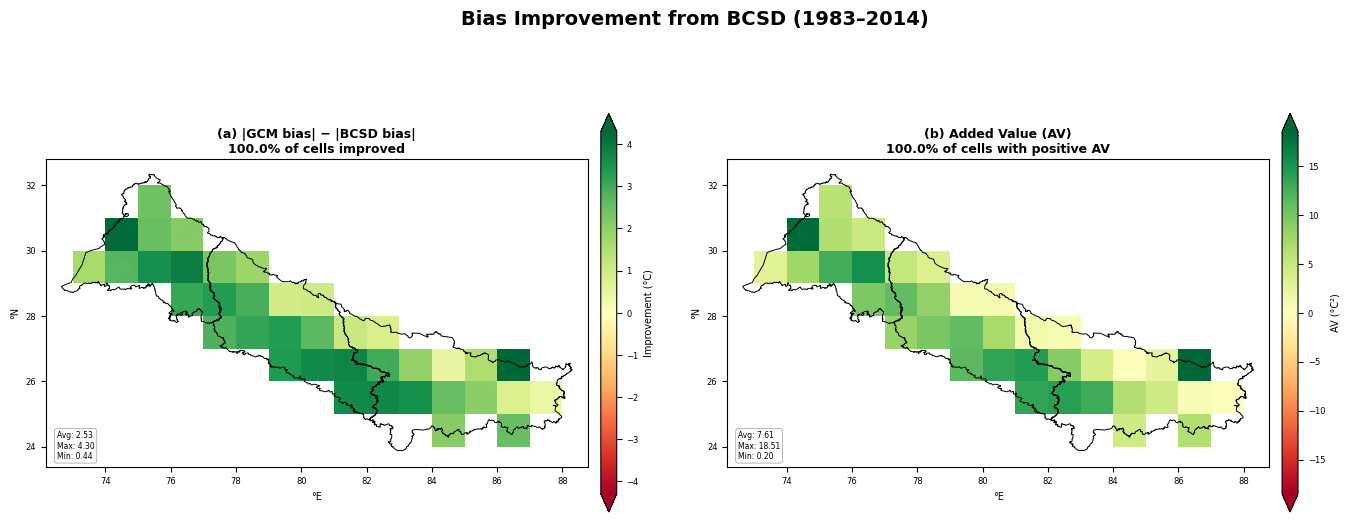

In [ ]:
gcm_bias_ann = (gcm_c.mean('time') - obs_c.mean('time')).compute()
bcsd_bias_ann = (bcsd.mean('time') - obs_f.mean('time')).compute()

# Bring GCM bias to 0.05° grid for direct comparison
gcm_bias_fine = gcm_bias_ann.interp(lat=bcsd_bias_ann.lat,
                                     lon=bcsd_bias_ann.lon,
                                     method='nearest')
improvement = np.abs(gcm_bias_fine) - np.abs(bcsd_bias_ann)

n_improved = int((improvement > 0).sum())
n_total = int((~np.isnan(improvement)).sum())
pct_improved = 100 * n_improved / n_total if n_total > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ilim = max(float(np.nanpercentile(np.abs(improvement), 98)), 0.5)
plot_india(axes[0], improvement,
           f'(a) |GCM bias| − |BCSD bias|\n{pct_improved:.1f}% of cells improved',
           'RdYlGn', -ilim, ilim, 'Improvement (°C)', center=0)

# Added Value (Tran-Anh Eq. 1). NOTE: this approximates AV using the squared
# *time-mean* bias, AV ≈ (mean_bias_GCM)^2 − (mean_bias_BCSD)^2. The rigorous form
# uses per-timestep MSE: AV = MSE(GCM,OBS) − MSE(BCSD,OBS). See message for the
# drop-in rigorous version if you want variance error included.
av = gcm_bias_fine**2 - bcsd_bias_ann**2
av_pct = 100 * int((av > 0).sum()) / int((~np.isnan(av)).sum())
av_lim = max(float(np.nanpercentile(np.abs(av), 98)), 1.0)
plot_india(axes[1], av,
           f'(b) Added Value (AV)\n{av_pct:.1f}% of cells with positive AV',
           'RdYlGn', -av_lim, av_lim, 'AV (°C²)', center=0)

fig.suptitle(f'Bias Improvement from BCSD ({EVAL_START}–{EVAL_END})',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig8_improvement.png', dpi=DPI,
            bbox_inches='tight', facecolor='white')
plt.show()

# ── Summary table (3 stages) ──
gcm_r  = xr.corr(daily_anom(gcm_c), daily_anom(obs_c), dim='time').compute()
bc_r   = xr.corr(daily_anom(bc_c),  daily_anom(obs_c), dim='time').compute()
bcsd_r = xr.corr(daily_anom(bcsd), daily_anom(obs_f), dim='time').compute()

gcm_rmse_v  = np.sqrt(((gcm_c - obs_c)**2).mean('time')).compute()
bc_rmse_v   = np.sqrt(((bc_c - obs_c)**2).mean('time')).compute()
bcsd_rmse_v = np.sqrt(((bcsd - obs_f)**2).mean('time')).compute()

summary = pd.DataFrame({
    'Resolution': ['1°', '1°', '0.05°'],
    'Mean Bias (°C)': [
        float(gcm_bias_ann.mean()),
        float((bc_c.mean('time') - obs_c.mean('time')).compute().mean()),
        float(bcsd_bias_ann.mean()),
    ],
    'MAE (°C)': [
        float(np.abs(gcm_bias_ann).mean()),
        float(np.abs((bc_c.mean('time') - obs_c.mean('time')).compute()).mean()),
        float(np.abs(bcsd_bias_ann).mean()),
    ],
    'RMSE (°C)': [
        float(gcm_rmse_v.mean()),
        float(bc_rmse_v.mean()),
        float(bcsd_rmse_v.mean()),
    ],
    'Daily Anom Corr': [
        float(gcm_r.mean()),
        float(bc_r.mean()),
        float(bcsd_r.mean()),
    ],
    'Seasonal Cycle Corr': [
        float(np.nanmean(gcm_sc_r)),
        float(np.nanmean(bc_sc_r)),
        float(np.nanmean(bcsd_sc_r)),
    ],
}, index=['Raw GCM', 'QM-corrected', 'BCSD']).round(3)

print("\n" + "=" * 65)
print("  3-STAGE EVALUATION SUMMARY")
print("=" * 65)
print(summary.to_string())
summary.to_csv(f'{FIG_DIR}/metrics_3stage.csv')
print(f"\nAll {len(os.listdir(FIG_DIR))} files saved in: {FIG_DIR}")